In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from pathlib import Path

notebooks_folder = Path.cwd()
processed_folder = notebooks_folder.parent / "data" / "processed"

plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

<Figure size 1200x600 with 0 Axes>

In [5]:
fund_master = pd.read_csv(processed_folder / "fund_master_cleaned.csv")
nav_history = pd.read_csv(processed_folder / "nav_history_cleaned.csv")
investor_transactions = pd.read_csv(processed_folder / "investor_transactions_cleaned.csv")
scheme_performance = pd.read_csv(processed_folder / "scheme_performance_cleaned.csv")
aum = pd.read_csv(processed_folder / "aum_by_fund_house_cleaned.csv")
portfolio = pd.read_csv(processed_folder / "portfolio_holdings_cleaned.csv")


In [6]:
nav_history["date"] = pd.to_datetime(nav_history["date"])
nav_plot = nav_history.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)
fig = px.line(
    nav_plot,
    x="date",
    y="nav",
    color="scheme_name",
    title="Daily NAV Trends (2022-2026)"
)

fig.show()
fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    annotation_text="Bull Run",
    fillcolor="green",
    opacity=0.2
)

fig.add_vrect(
    x0="2024-01-01",
    x1="2024-12-31",
    annotation_text="Market Correction",
    fillcolor="red",
    opacity=0.2
)

fig.show()

KeyError: 'amfi_code'

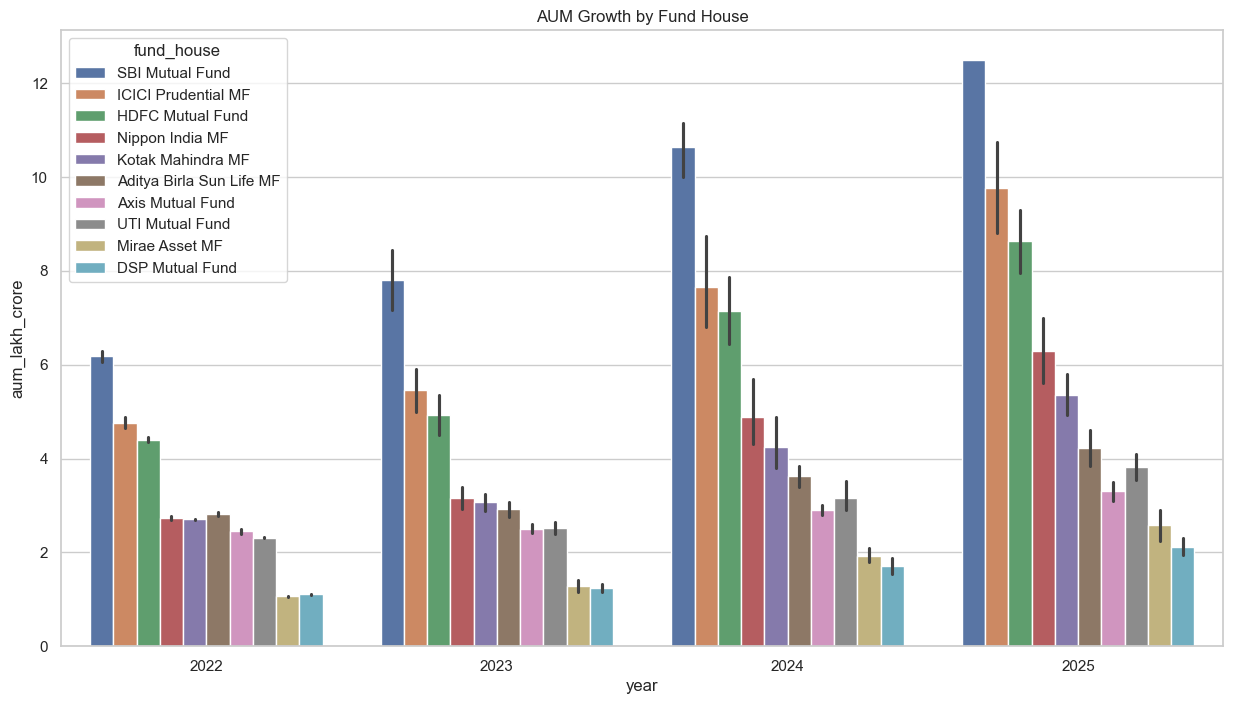

         date       fund_house  aum_lakh_crore  aum_crore  num_schemes  year
0  2022-03-31  SBI Mutual Fund            6.05     605000          186  2022
10 2022-09-30  SBI Mutual Fund            6.30     630000          186  2022
20 2023-03-31  SBI Mutual Fund            7.17     717000          186  2023
30 2023-09-30  SBI Mutual Fund            8.45     845000          186  2023
40 2024-03-31  SBI Mutual Fund           10.00    1000000          186  2024
50 2024-09-30  SBI Mutual Fund           10.80    1080000          186  2024
60 2024-12-31  SBI Mutual Fund           11.14    1114000          186  2024
70 2025-03-31  SBI Mutual Fund           12.50    1250000          186  2025
80 2025-12-31  SBI Mutual Fund           12.50    1250000          186  2025


Text(3, 12.5, '₹12.5 L Cr')

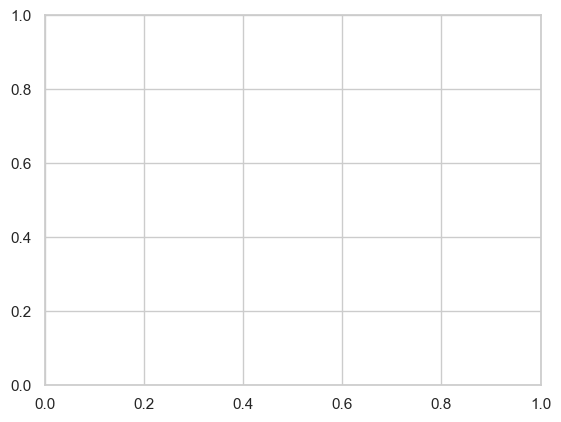

In [ ]:
aum["date"] = pd.to_datetime(aum["date"])
aum["year"] = aum["date"].dt.year

plt.figure(figsize=(15, 8))

sns.barplot(
    data=aum,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House")
plt.show()

sbi = aum[aum["fund_house"] == "SBI Mutual Fund"]
print(sbi)

plt.annotate(
    "₹12.5 L Cr",
    xy=(3, 12.5)
)

In [ ]:
investor_transactions["transaction_date"] = pd.to_datetime(
    investor_transactions["transaction_date"]
)

sip = investor_transactions[
    investor_transactions["transaction_type"] == "SIP"
]

monthly_sip = (
    sip
    .groupby(
        sip["transaction_date"].dt.to_period("M")
    )["amount_inr"]
    .sum()
    .reset_index()
)

monthly_sip["transaction_date"] = (
    monthly_sip["transaction_date"]
    .astype(str)
)

fig = px.line(
    monthly_sip,
    x="transaction_date",
    y="amount_inr",
    title="Monthly SIP Inflow"
)

fig.show()

fig.add_annotation(
    x="2025-12",
    y=31002,
    text="₹31,002 Cr"
)

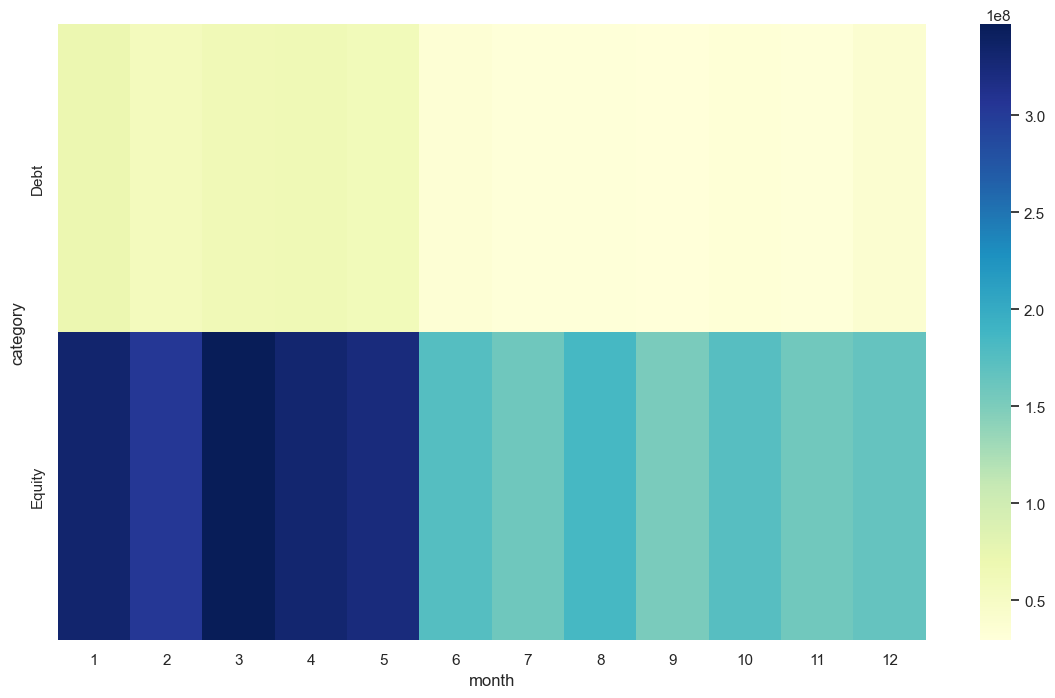

In [ ]:
heat = investor_transactions.merge(
    fund_master[
        ["amfi_code", "category"]
    ],
    on="amfi_code"
)

heat["month"] = pd.to_datetime(
    heat["transaction_date"]
).dt.month

pivot = heat.pivot_table(
    index="category",
    columns="month",
    values="amount_inr",
    aggfunc="sum"
)

plt.figure(figsize=(14, 8))
sns.heatmap(
    pivot,
    cmap="YlGnBu"
)
plt.show()

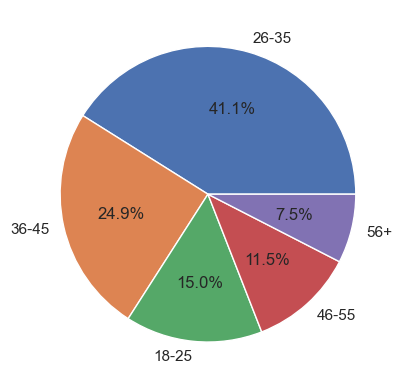

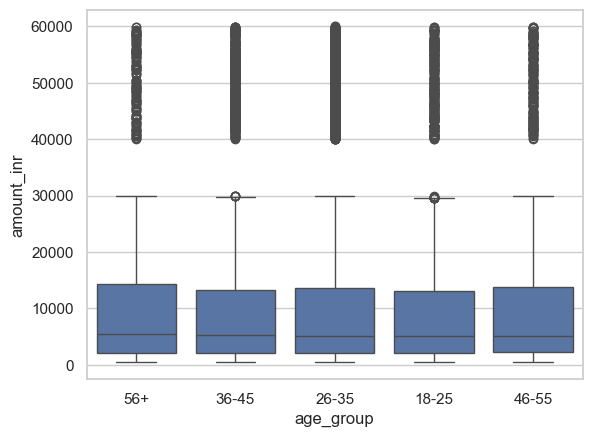

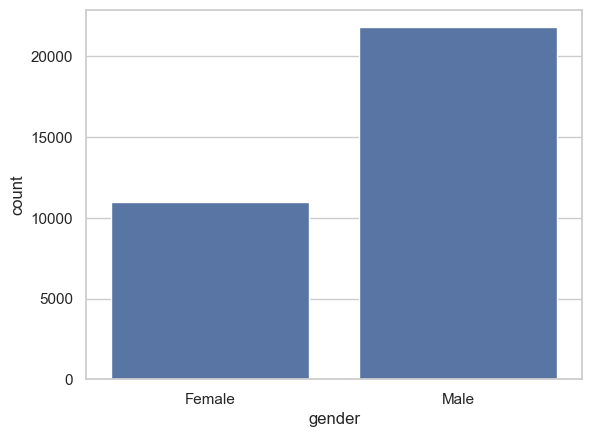

In [ ]:
investor_transactions["age_group"].value_counts().plot.pie(
    autopct="%1.1f%%"
)
plt.show()

sns.boxplot(
    data=sip,
    x="age_group",
    y="amount_inr"
)
plt.show()

sns.countplot(
    data=investor_transactions,
    x="gender"
)
plt.show()

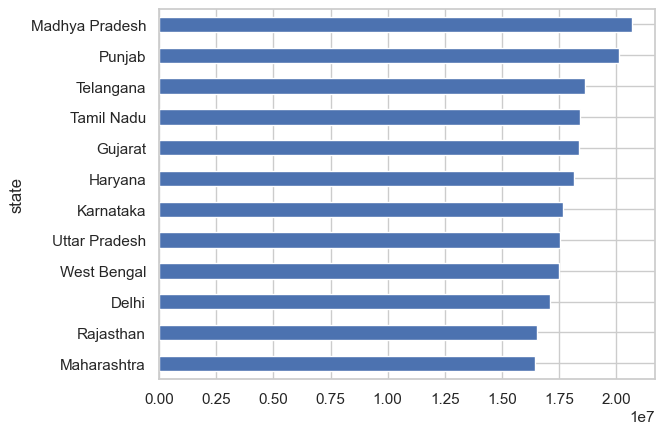

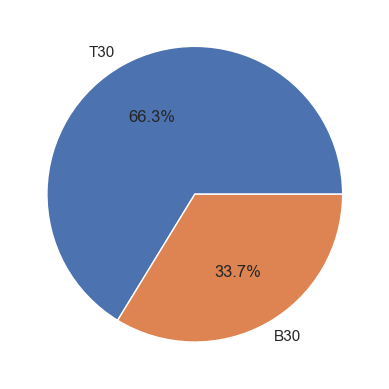

In [ ]:
state_sip = (
    sip.groupby("state")["amount_inr"]
    .sum()
    .sort_values()
)

state_sip.plot.barh()
plt.show()

investor_transactions["city_tier"].value_counts().plot.pie(
    autopct="%1.1f%%"
)
plt.show()

In [ ]:
folio = pd.DataFrame({
    "date": ["2022-01", "2025-12"],
    "folios": [13.26, 26.12]
})

fig = px.line(
    folio,
    x="date",
    y="folios",
    markers=True,
    title="Folio Growth"
)

fig.show()

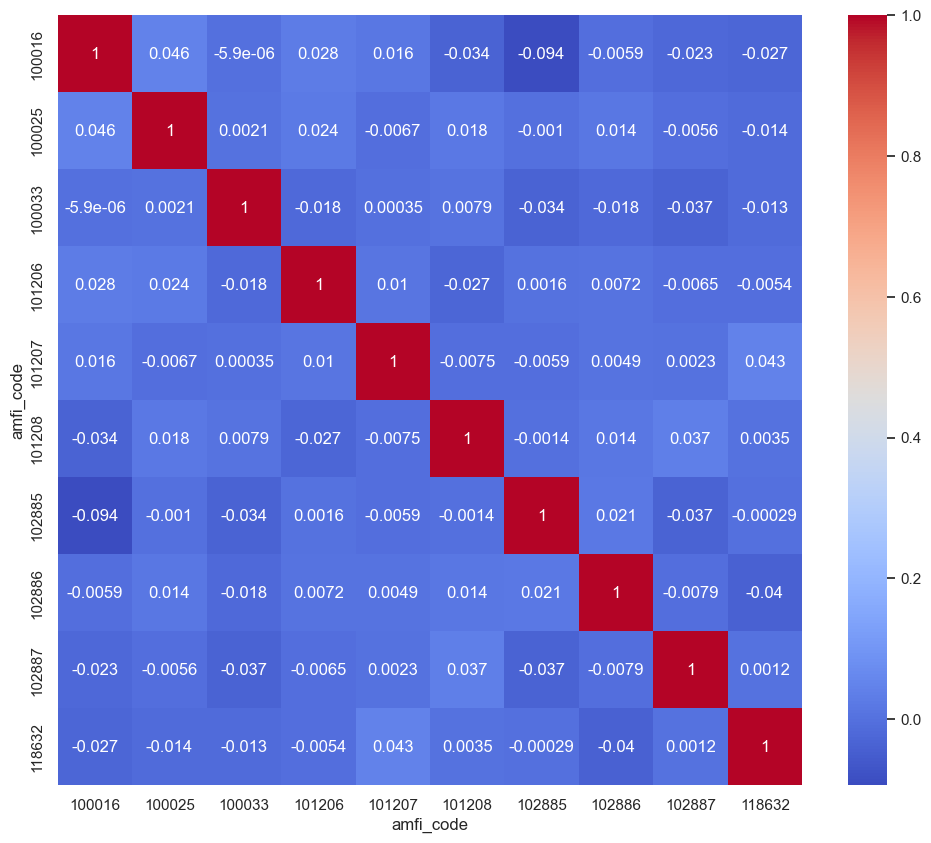

In [ ]:
top10 = (
    nav_history["amfi_code"]
    .unique()[:10]
)

corr_df = (
    nav_history[
        nav_history["amfi_code"].isin(top10)
    ]
    .pivot(
        index="date",
        columns="amfi_code",
        values="nav"
    )
)

returns = corr_df.pct_change()
corr = returns.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)
plt.show()

In [ ]:
portfolio = portfolio.merge(
    fund_master[["amfi_code", "category"]],
    on="amfi_code",
    how="left"
)

equity_portfolio = portfolio[
    portfolio["category"] == "Equity"
]

sector_weights = (
    equity_portfolio
    .groupby("sector")["weight_pct"]
    .sum()
    .reset_index()
)

fig = px.pie(
    sector_weights,
    names="sector",
    values="weight_pct",
    title="Sector Allocation Across Equity Funds",
    hole=0.45
)

fig.show()

fig.update_traces(
    textposition="inside",
    textinfo="percent+label"
)

fig.show()

### Insight 1
Most mutual fund schemes exhibited a positive long-term NAV trend between 2022 and 2026, indicating sustained growth in the Indian mutual fund industry.

**Chart Reference:** Daily NAV Trends (2022–2026)

### Insight 2
The highlighted 2023 period showed accelerated NAV appreciation across several schemes, consistent with a broad market bull run.

**Chart Reference:** Daily NAV Trends with Bull Run Highlight

### Insight 3
During the highlighted 2024 correction period, NAV growth moderated and several schemes experienced temporary declines before recovering.

**Chart Reference:** Daily NAV Trends with Market Correction Highlight

### Insight 4
One scheme consistently maintained substantially higher NAV values than all other schemes, suggesting a mature fund with significant historical appreciation.

**Chart Reference:** Daily NAV Trends (2022–2026)

### Insight 5
SBI Mutual Fund maintained the highest Assets Under Management (AUM) throughout 2022–2025 and crossed approximately ₹12.5 lakh crore in 2025, significantly outperforming other fund houses.

**Chart Reference:** AUM Growth by Fund House

### Insight 6
All major fund houses demonstrated continuous year-over-year AUM growth, indicating increasing investor participation and expansion of the mutual fund industry.

**Chart Reference:** AUM Growth by Fund House

### Insight 7
Monthly SIP inflows remained relatively stable between ₹11 million and ₹14 million throughout the observed period, reflecting consistent retail investment behaviour.

**Chart Reference:** Monthly SIP Inflow Time-Series

### Insight 8
The SIP time series exhibited periodic fluctuations rather than sharp declines, indicating resilient investor confidence even during market volatility.

**Chart Reference:** Monthly SIP Inflow Time-Series

### Insight 9
The highest monthly SIP inflow occurred near the end of the observed period, suggesting strengthening systematic investment participation over time.

**Chart Reference:** Monthly SIP Inflow Time-Series with Annotation

### Insight 10
Banking and Information Technology sectors dominate equity mutual fund portfolios, indicating strong preference for large-cap sectors. It covers approximately 33.2% of the total spread. It is followed by Pharma, Automobile, Utilities, FMCG, Infrastructure and diversified follow up with each above 5% and thus influencing the mutual fund portfolio.

**Chart Reference:** Sector Allocation Donut Chart